# 时间序列数据及特征提取

## 1. 学习目标

通过本章的学习，读者将能够：

1. **理解** 时间序列数据的定义、类型及其在各领域的应用场景。
2. **掌握** 时间序列分析的三大核心任务：预测、分类/回归与异常检测。
3. **深入理解** 时间序列的关键统计特性：**平稳性（Stationarity）**、**自相关性（Autocorrelation）** 与 **白噪声（White Noise）**。
4. **熟练运用** 常见的时间序列特征提取方法，包括滞后特征、滑动窗口统计、**循环时间编码（Cyclical Encoding）** 及周期性分析。
5. **掌握** 时间序列的科学建模流程，包括**时间序列交叉验证（TimeSeriesSplit）** 与评估指标的选择。
6. **应用** Python 工具库（`pandas`、`statsmodels`、`sklearn`）完成从数据预处理到建模的全流程。

---

## 2. 引言

### 2.1 什么是时间序列数据？

**时间序列数据（Time Series Data）** 是指按照时间顺序索引的一系列数据点。与传统的横截面数据（Cross-sectional Data）不同，时间序列数据最显著的特征是数据点之间存在**时间依赖性**（Temporal Dependence），即当前时刻的状态往往受过去时刻状态的影响。

### 2.2 应用场景

时间序列数据的应用无处不在，涵盖了从宏观经济到微观行为的各个层面：

- **金融领域**：股票价格预测、高频交易波动率分析。
- **气象领域**：气温、降雨量预测，气候变化趋势分析。
- **工业制造**：设备传感器监控、故障预测性维护（Predictive Maintenance）。
- **医疗健康**：心电图（ECG）监测、生命体征趋势分析。
- **互联网**：网站流量预测、用户行为路径分析、广告点击率预估。

### 2.3 核心目标

时间序列分析旨在通过历史数据揭示其内在规律，并建立数学模型以实现：

1. **解释**：理解过去发生了什么（如分析季节性影响）。
2. **预测**：推断未来可能发生什么（如预测销量）。
3. **控制**：根据预测结果采取干预措施（如库存管理）。

### 2.4 关键统计概念

在深入分析之前，必须理解以下核心概念：

#### 1. 平稳性 (Stationarity)

平稳性是许多经典时间序列模型（如 ARIMA）的前提假设。一个平稳的时间序列满足：

- **均值常数**：不随时间变化（无明显趋势）。
- **方差常数**：波动幅度不随时间变化（无异方差性）。
- **自协方差**：仅与时间间隔（Lag）有关，与具体时间点无关。

> **如何检测？** 常用 **ADF 检验 (Augmented Dickey-Fuller Test)**。若 p-value < 0.05，则拒绝原假设，认为序列平稳。
> **如何处理？** 非平稳序列通常通过**差分 (Differencing)** 或 **对数变换** 转化为平稳序列。

#### 2. 自相关性 (Autocorrelation)

指时间序列与其自身滞后版本之间的相关性。通过 **ACF (自相关函数)** 和 **PACF (偏自相关函数)** 图，可以判断数据的记忆长度和季节性周期。

#### 3. 白噪声 (White Noise)

纯随机序列，均值为 0，方差恒定，且各观测值之间无相关性。如果一个模型的残差是白噪声，说明模型已经充分提取了数据中的有用信息。

---

## 3. 时间序列数据的类型

### 3.1 经典时间序列（Regular Time Series）

这类数据在**固定的时间间隔**内采样，具有等间距的特性。

**示例**：

- 每日股票收盘价
- 每小时气温记录

**数据结构**：
通常以 `timestamp`（时间戳）为索引，`value`（观测值）为列。



In [6]:
import pandas as pd

# 示例：生成每日时间序列
data = pd.DataFrame({
    'timestamp': pd.date_range(start='2024-01-01', periods=5, freq='D'),
    'value': [100, 102, 101, 105, 110]
}).set_index('timestamp')

print(data)

            value
timestamp        
2024-01-01    100
2024-01-02    102
2024-01-03    101
2024-01-04    105
2024-01-05    110



### 3.2 带时间戳的事件流（Irregular Event Streams）

这类数据记录的是离散事件的发生时刻，时间间隔**不固定**。

**示例**：

- 用户点击网站日志
- 银行账户交易记录

**处理方法**：
通常需要通过**重采样（Resampling）**（如 `resample('1H').count()`）将其转换为固定间隔的时间序列。

---

## 4. 常见分析任务

### 4.1 时间序列预测 (Forecasting)

基于历史序列值预测未来值。

- **常用模型**：`ARIMA`（统计学经典）、`Prophet`（加性模型）、`LSTM/Transformer`（深度学习）、`XGBoost/LightGBM`（机器学习回归）。

### 4.2 时间序列分类/回归 (Classification/Regression)

将整个时间序列作为一个样本进行分类或回归。

- **示例**：根据心电图判断疾病。
- **常用模型**：`1D-CNN`、`Shapelet`、`Rocket`。

### 4.3 异常检测 (Anomaly Detection)

识别不符合正常模式的离群点或子序列。

- **常用方法**：`Isolation Forest`、`3-Sigma 原则`、`AutoEncoder` 重构误差。

---

## 5. 核心特征提取方法

对于机器学习模型（如 XGBoost），必须将时序数据转化为**表格化特征**。

### 5.1 滞后特征（Lag Features）

**原理**：直接利用过去的值作为特征，捕捉**自相关性**。

**Python 实现**：



In [7]:
# 生成滞后特征：利用昨天和前天的值预测今天
data['lag_1'] = data['value'].shift(1)
data['lag_2'] = data['value'].shift(2)


### 5.2 滑动窗口统计（Rolling Window Statistics）

**原理**：在固定窗口内计算统计量，捕捉**局部趋势**和**波动性**。

- **Rolling Mean**：平滑噪音，提取趋势。
- **Rolling Std**：衡量波动风险（如金融风控）。
- **Expanding Window**：窗口随时间不断扩大，计算至今为止的累积统计量。
- **EWMA (指数加权移动平均)**：赋予近期数据更高权重，对变化反应更灵敏。

**Python 实现**：



In [8]:
# 滑动窗口
data['rolling_mean_3'] = data['value'].rolling(window=3).mean()

# 指数加权移动平均 (span=3)
data['ewma_3'] = data['value'].ewm(span=3).mean()


### 5.3 周期性与频域分析（Seasonality & FFT）

**原理**：利用 **FFT (快速傅里叶变换)** 识别数据的主频率（周期），如年、月、周周期。

### 5.4 时间特征与循环编码（Cyclical Encoding）

**重要概念**：
直接使用 `Hour` (0-23) 或 `Month` (1-12) 作为特征存在问题：数字 23 和 0 在数值上相差很大，但在时间意义上是连续的。

**解决方案**：
将时间变量映射到圆周上，使用 **Sine/Cosine 变换** 保持连续性。

$$
x_{sin} = \sin(\frac{2 \pi \times t}{T}), \quad x_{cos} = \cos(\frac{2 \pi \times t}{T})
$$

其中 $T$ 是周期（如 24 小时、12 个月）。

**Python 实现**：



In [9]:
import pandas as pd
import numpy as np

# 生成示例数据：24小时
df = pd.DataFrame({'hour': range(24)})

# 循环编码
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# 查看前几行
print(df.head())

   hour  hour_sin  hour_cos
0     0  0.000000  1.000000
1     1  0.258819  0.965926
2     2  0.500000  0.866025
3     3  0.707107  0.707107
4     4  0.866025  0.500000



### 5.5 时序分解（Time Series Decomposition）

将序列分解为 **趋势 (Trend)**、**季节性 (Seasonality)** 和 **残差 (Residual)**。

- **STL 分解 (Seasonal-Trend decomposition using Loess)**：比经典分解更鲁棒，能处理随时间变化的季节性。

---

## 6. Python 综合实践

本节演示从数据生成、可视化、特征工程到建模验证的完整流程。为了方便演示，我们使用模拟的**非平稳**时间序列数据。

### 6.1 数据生成与探索性分析



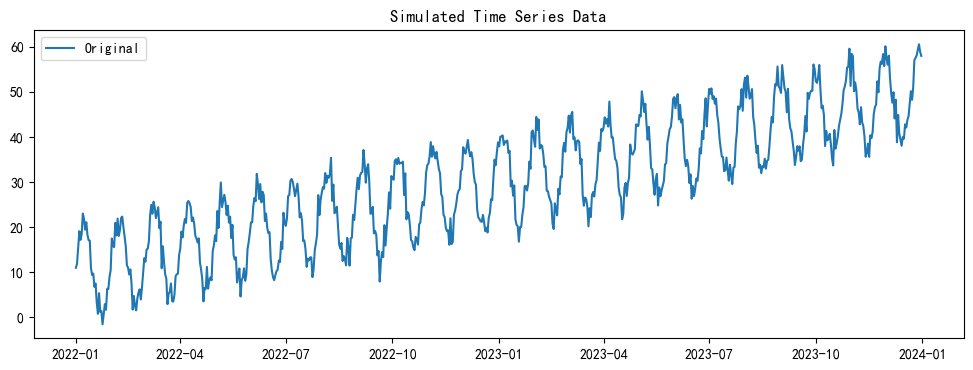

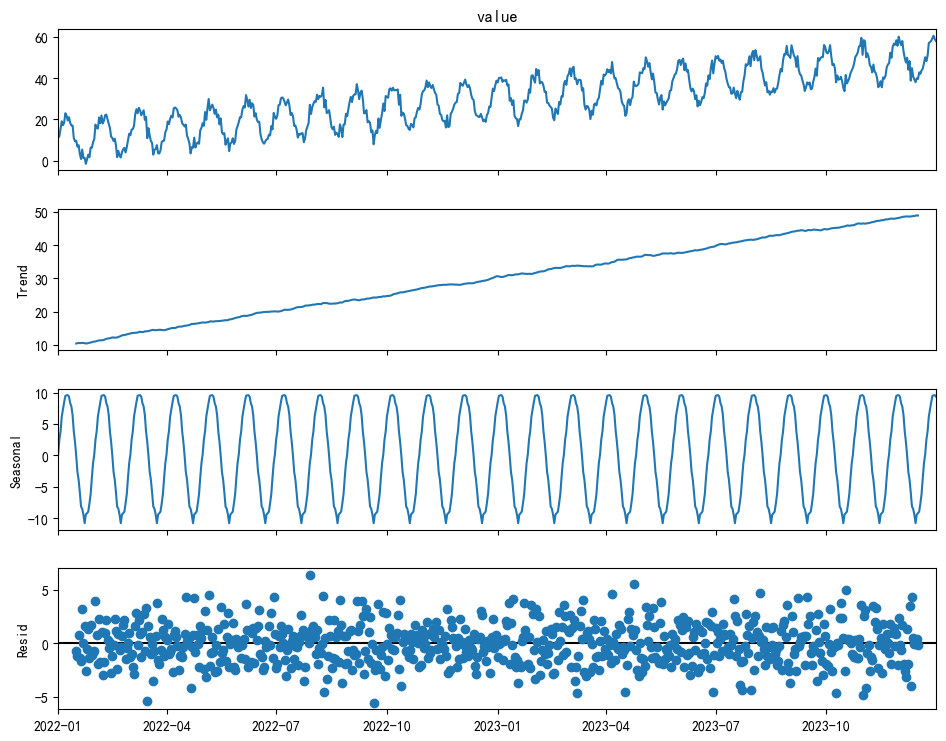

原始序列 ADF p-value: 0.9088
>> 序列非平稳，尝试一阶差分...
一阶差分后 ADF p-value: 0.0000


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. 生成模拟数据 (趋势 + 周期 + 噪声)
np.random.seed(42)
n_samples = 365 * 2  # 两年数据
dates = pd.date_range(start='2022-01-01', periods=n_samples, freq='D')

# 线性趋势 + 正弦周期 (30天周期) + 随机噪声
values = np.linspace(10, 50, n_samples) + \
         10 * np.sin(2 * np.pi * np.arange(n_samples) / 30) + \
         np.random.normal(0, 2, n_samples)

df = pd.DataFrame({'date': dates, 'value': values}).set_index('date')

# 2. 可视化原始数据
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['value'], label='Original')
plt.title('Simulated Time Series Data')
plt.legend()
plt.show()

# 3. 时序分解 (STL)
# 观察数据的 趋势(Trend)、季节性(Seasonal) 和 残差(Resid)
decomposition = seasonal_decompose(df['value'], model='additive', period=30)
fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.show()

# 4. 平稳性检验 (ADF Test)
result = adfuller(df['value'])
print(f"原始序列 ADF p-value: {result[1]:.4f}")

if result[1] > 0.05:
    print(">> 序列非平稳，尝试一阶差分...")
    df['diff_1'] = df['value'].diff()
    # 再次检验差分后的序列
    result_diff = adfuller(df['diff_1'].dropna())
    print(f"一阶差分后 ADF p-value: {result_diff[1]:.4f}")
else:
    print(">> 序列平稳。")


### 6.2 高级特征工程

构建用于监督学习的特征集。



In [11]:
# 1. 基础滞后特征 (Lag Features)
# 利用过去 1天、7天、30天 的值预测未来
for lag in [1, 7, 30]:
    df[f'lag_{lag}'] = df['value'].shift(lag)

# 2. 滑动窗口统计 (Rolling Window Features)
# 计算过去 7 天的均值和标准差
df['rolling_mean_7'] = df['value'].rolling(window=7).mean()
df['rolling_std_7'] = df['value'].rolling(window=7).std()

# 3. 循环时间编码 (Cyclical Encoding)
# 将“月份”和“星期几”映射到圆周上，保持时间的连续性
df['month'] = df.index.month
df['day_of_week'] = df.index.dayofweek

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# 删除因 shift 和 diff 产生的 NaN 值
df.dropna(inplace=True)

print(f"特征矩阵维度: {df.shape}")
# 查看前几行特征
print(df[['value', 'lag_1', 'rolling_mean_7', 'month_sin']].head())


特征矩阵维度: (700, 13)
                value      lag_1  rolling_mean_7  month_sin
date                                                       
2022-01-31  10.442677   8.928716        5.334025   0.500000
2022-02-01  17.484633  10.442677        7.729324   0.866025
2022-02-02  15.796202  17.484633        9.566877   0.866025
2022-02-03  15.573130  15.796202       11.549727   0.866025
2022-02-04  20.942107  15.573130       13.633596   0.866025



### 6.3 科学的模型验证 (TimeSeriesSplit)

**注意**：时间序列**不能**使用随机 `K-Fold` 交叉验证，因为这会引入“未来数据泄露”（Look-ahead Bias）。必须使用**时间序列交叉验证 (TimeSeriesSplit)**，即“前向验证”。




开始时间序列交叉验证...
Fold 1: Train size=120, Test size=116, RMSE=4.7231
Fold 2: Train size=236, Test size=116, RMSE=6.0744
Fold 3: Train size=352, Test size=116, RMSE=5.0267
Fold 4: Train size=468, Test size=116, RMSE=5.4143
Fold 5: Train size=584, Test size=116, RMSE=4.1828

Average RMSE: 5.0843


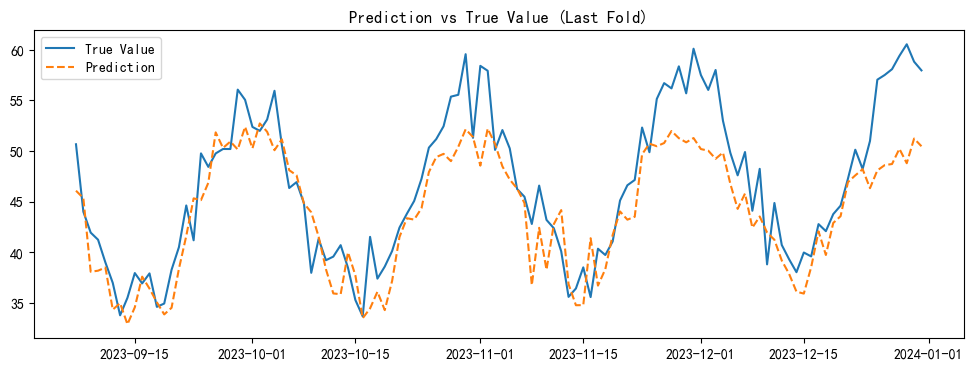

In [12]:
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# 准备数据：移除不需要的列
features = [col for col in df.columns if col not in ['value', 'diff_1', 'date', 'month', 'day_of_week']]
X = df[features]
y = df['value']

# 初始化 TimeSeriesSplit (5折)
tscv = TimeSeriesSplit(n_splits=5)
model = XGBRegressor(n_estimators=100, max_depth=5, random_state=42)
scores = []

print("\n开始时间序列交叉验证...")
for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    scores.append(rmse)
    print(f"Fold {fold+1}: Train size={len(train_index)}, Test size={len(test_index)}, RMSE={rmse:.4f}")

print(f"\nAverage RMSE: {np.mean(scores):.4f}")

# 可视化最后一折的预测结果
plt.figure(figsize=(12, 4))
plt.plot(y_test.index, y_test, label='True Value')
plt.plot(y_test.index, preds, label='Prediction', linestyle='--')
plt.title('Prediction vs True Value (Last Fold)')
plt.legend()
plt.show()


---

## 7. 练习与思考

1. **思考**：为什么在时间序列回归中，随机打乱数据（Shuffle）会导致模型性能虚高？
2. **实践**：对一份非平稳的股票数据（如收盘价）进行一阶差分，观察其 ACF 和 PACF 图的变化。
3. **探索**：了解 **Prophet** 模型是如何自动处理节假日（Holidays）和突变点（Changepoints）的。

---

## 8. 总结与展望

本章不仅介绍了时间序列的基础概念，还深入探讨了**平稳性**、**循环编码**和**前向验证**等高级主题。

- **特征工程** 是提升机器学习模型（如 XGBoost）在时序任务上表现的核心。
- **正确的验证策略** 是模型上线后效果符合预期的保障。

后续可进一步学习 **DeepAR**、**Temporal Fusion Transformer (TFT)** 等前沿深度学习模型，它们在处理多变量、长序列预测上展现了强大的能力。

---

## 9. 参考文献

1. Hyndman, R. J., & Athanasopoulos, G. (2018). _Forecasting: principles and practice_. OTexts.
2. Box, G. E., Jenkins, G. M., Reinsel, G. C., & Ljung, G. M. (2015). _Time series analysis: forecasting and control_. John Wiley & Sons.
3. [Statsmodels Documentation](https://www.statsmodels.org/stable/tsa.html)
